In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", gpus)

if gpus:
    print("GPU ready ✅")
else:
    print("⚠️ GPU not detected")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU ready ✅


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/dataset_cropped"

In [ ]:
import os

CLASS_NAMES = [
    "clean",
    "low",
    "medium",
    "high"
]

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

print("====================================")
print("FINAL DATASET CHECK")
print("====================================")

total = 0

for class_name in CLASS_NAMES:

    folder = os.path.join(
        DATASET_DIR,
        class_name
    )

    if not os.path.exists(folder):
        print(f"❌ {class_name}: FOLDER NOT FOUND")
        continue

    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ]

    print(
        f"{class_name:<10} : {len(files)} images"
    )

    total += len(files)

print("------------------------------------")
print("TOTAL      :", total)
print("====================================")

FINAL DATASET CHECK
clean      : 50 images
low        : 50 images
medium     : 50 images
high       : 50 images
------------------------------------
TOTAL      : 200


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# ============================================================
# PATHS
# ============================================================

SPLIT_DIR = "/content/dataset_split"

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR   = os.path.join(SPLIT_DIR, "val")
TEST_DIR  = os.path.join(SPLIT_DIR, "test")


# ============================================================
# REMOVE OLD SPLIT IF CELL IS RE-RUN
# ============================================================

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)


# ============================================================
# CREATE SPLIT
# ============================================================

for class_name in CLASS_NAMES:

    source_folder = os.path.join(
        DATASET_DIR,
        class_name
    )

    images = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    ]

    images.sort()

    # --------------------------------------------------------
    # 70% TRAIN / 30% TEMP
    # --------------------------------------------------------

    train_files, temp_files = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    # --------------------------------------------------------
    # Split remaining 30% equally:
    # 15% validation / 15% test
    # --------------------------------------------------------

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42
    )


    split_data = {
        TRAIN_DIR: train_files,
        VAL_DIR: val_files,
        TEST_DIR: test_files
    }


    # --------------------------------------------------------
    # COPY FILES
    # --------------------------------------------------------

    for destination_root, file_list in split_data.items():

        destination_folder = os.path.join(
            destination_root,
            class_name
        )

        os.makedirs(
            destination_folder,
            exist_ok=True
        )

        for filename in file_list:

            source_path = os.path.join(
                source_folder,
                filename
            )

            destination_path = os.path.join(
                destination_folder,
                filename
            )

            shutil.copy2(
                source_path,
                destination_path
            )


# ============================================================
# VERIFY
# ============================================================

print("========================================")
print("DATASET SPLIT COMPLETE")
print("========================================")

for class_name in CLASS_NAMES:

    train_count = len(
        os.listdir(
            os.path.join(TRAIN_DIR, class_name)
        )
    )

    val_count = len(
        os.listdir(
            os.path.join(VAL_DIR, class_name)
        )
    )

    test_count = len(
        os.listdir(
            os.path.join(TEST_DIR, class_name)
        )
    )

    print(
        f"{class_name:<10} "
        f"Train: {train_count:<3} "
        f"Val: {val_count:<3} "
        f"Test: {test_count:<3}"
    )

print("========================================")

DATASET SPLIT COMPLETE
clean      Train: 35  Val: 7   Test: 8  
low        Train: 35  Val: 7   Test: 8  
medium     Train: 35  Val: 7   Test: 8  
high       Train: 35  Val: 7   Test: 8  


In [ ]:
import tensorflow as tf

# ============================================================
# SETTINGS
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42


# ============================================================
# TRAIN DATASET
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


# ============================================================
# VALIDATION DATASET
# ============================================================

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# TEST DATASET
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# CHECK CLASSES
# ============================================================

class_names = train_ds.class_names

print()
print("====================================")
print("DATASET LOADED")
print("====================================")

print("Classes:", class_names)
print("Number of classes:", len(class_names))

print("====================================")

Found 140 files belonging to 4 classes.
Found 28 files belonging to 4 classes.
Found 32 files belonging to 4 classes.

DATASET LOADED
Classes: ['clean', 'high', 'low', 'medium']
Number of classes: 4


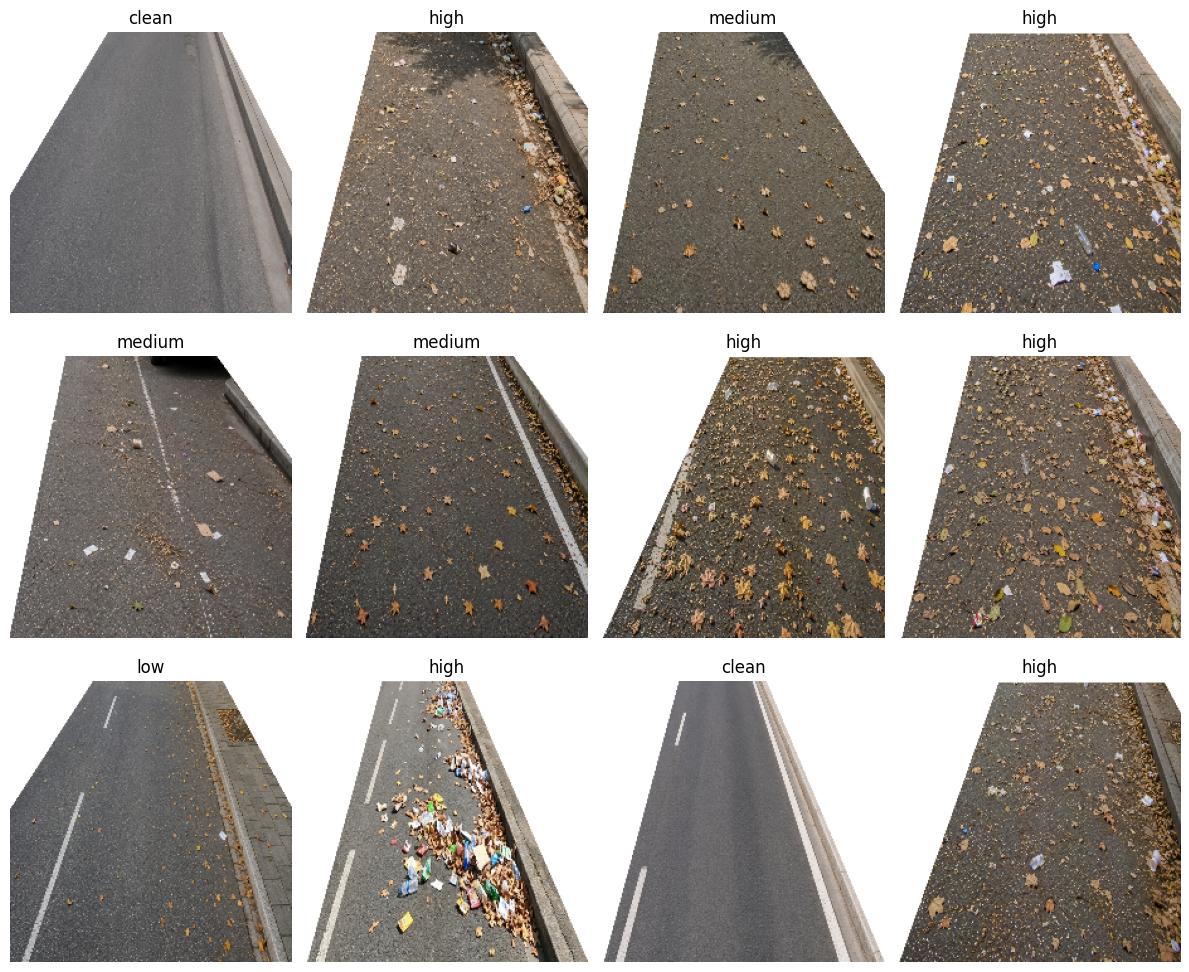

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

for images, labels in train_ds.take(1):

    for i in range(min(12, len(images))):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            class_names[int(labels[i])]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

print("Data augmentation ready ✅")

Data augmentation ready ✅


In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained MobileNet layers
base_model.trainable = False

print("MobileNetV2 loaded ✅")
print("Base model trainable:", base_model.trainable)
print("Layers:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 loaded ✅
Base model trainable: False
Layers: 154


In [ ]:
from tensorflow import keras
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

NUM_CLASSES = len(class_names)

inputs = keras.Input(
    shape=(224, 224, 3)
)

# ------------------------------------------------------------
# AUGMENTATION
# ------------------------------------------------------------

x = data_augmentation(inputs)


# ------------------------------------------------------------
# MOBILENET PREPROCESSING
# Converts pixel values into the format expected by MobileNetV2
# ------------------------------------------------------------

x = preprocess_input(x)


# ------------------------------------------------------------
# PRETRAINED MOBILENET
# ------------------------------------------------------------

x = base_model(
    x,
    training=False
)


# ------------------------------------------------------------
# CLASSIFICATION HEAD
# ------------------------------------------------------------

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


# ------------------------------------------------------------
# FINAL MODEL
# ------------------------------------------------------------

model = keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("Model compiled ✅")

Model compiled ✅


In [ ]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 489ms/step - accuracy: 0.2357 - loss: 1.6736 - val_accuracy: 0.3929 - val_loss: 1.2605 - learning_rate: 0.0010
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step - accuracy: 0.4786 - loss: 1.1164 - val_accuracy: 0.6429 - val_loss: 0.8502 - learning_rate: 0.0010
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 494ms/step - accuracy: 0.7143 - loss: 0.7781 - val_accuracy: 0.7857 - val_loss: 0.6504 - learning_rate: 0.0010
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 448ms/step - accuracy: 0.6929 - loss: 0.7181 - val_accuracy: 0.8929 - val_loss: 0.5259 - learning_rate: 0.0010
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.7714 - loss: 0.5531 - val_accuracy: 0.8571 - val_loss: 0.4711 - learning_rate: 0.0010
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 320ms/step - accuracy: 0.7929 - loss: 0.5171 - val_accuracy: 0.8571 - val_loss: 0.4309 - learning_rate: 0.0010
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 523ms/step - accuracy: 0.8000 - loss: 0.5092 - val_accuracy:

In [ ]:
# ============================================================
# EVALUATE ON UNTOUCHED TEST DATA
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print()
print("======================================")
print("TEST RESULTS")
print("======================================")

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

print("======================================")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step - accuracy: 0.9062 - loss: 0.3317

TEST RESULTS
Test Accuracy : 90.62%
Test Loss     : 0.3317


In [ ]:
# ============================================================
# TEST SET PREDICTIONS
# ============================================================

import numpy as np

y_true = []
y_pred = []
y_confidence = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    confidence = np.max(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_classes
    )

    y_confidence.extend(
        confidence
    )


y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_confidence = np.array(y_confidence)

print("Predictions complete ✅")
print("Test samples:", len(y_true))

Predictions complete ✅
Test samples: 32


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       clean     1.0000    0.8750    0.9333         8
        high     0.8889    1.0000    0.9412         8
         low     0.8000    1.0000    0.8889         8
      medium     1.0000    0.7500    0.8571         8

    accuracy                         0.9062        32
   macro avg     0.9222    0.9062    0.9051        32
weighted avg     0.9222    0.9062    0.9051        32



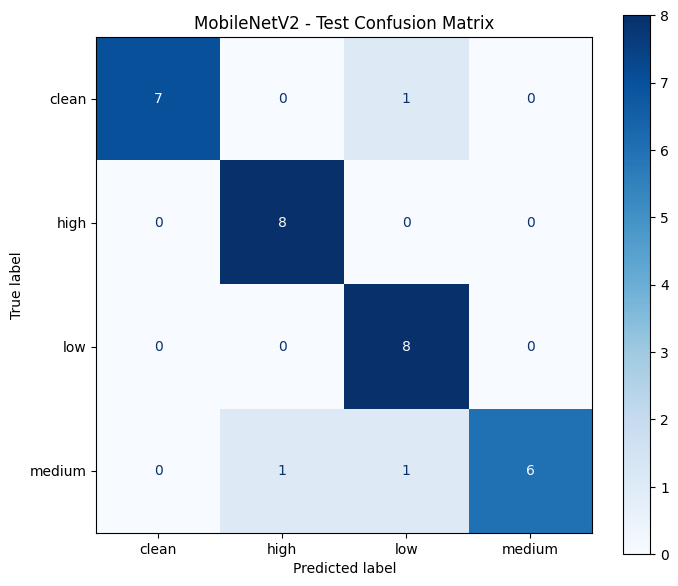

In [ ]:
# ============================================================
# CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "MobileNetV2 - Test Confusion Matrix"
)

plt.show()

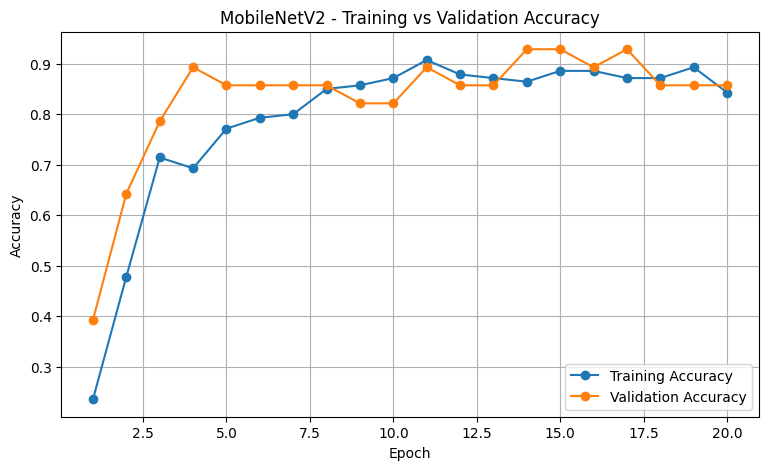

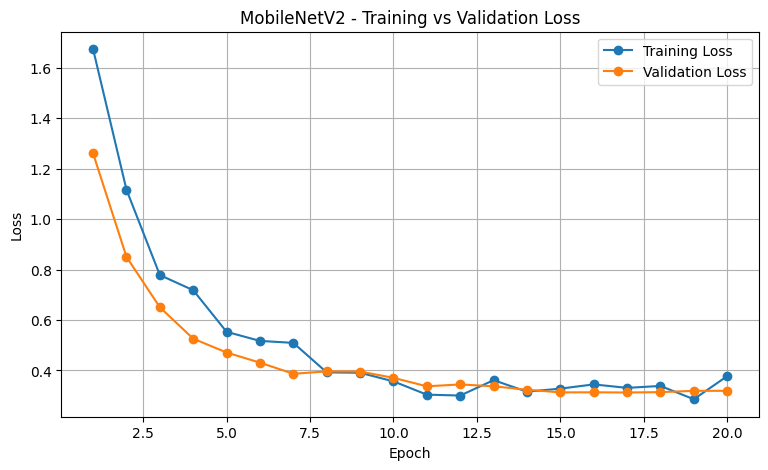

In [ ]:
# ============================================================
# TRAINING HISTORY
# ============================================================

import matplotlib.pyplot as plt

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_acc) + 1)


# ============================================================
# ACCURACY CURVE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_range,
    train_acc,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_acc,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("MobileNetV2 - Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_range,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("MobileNetV2 - Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# FIND MISCLASSIFIED IMAGES
# ============================================================

wrong_indices = np.where(
    y_true != y_pred
)[0]

print("======================================")
print("MISCLASSIFIED TEST IMAGES")
print("======================================")

print("Total test images :", len(y_true))
print("Correct           :", np.sum(y_true == y_pred))
print("Incorrect         :", len(wrong_indices))

print()

for idx in wrong_indices:

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]
    confidence = y_confidence[idx]

    print(
        f"Index {idx:02d} | "
        f"Actual: {actual:<8} | "
        f"Predicted: {predicted:<8} | "
        f"Confidence: {confidence*100:.2f}%"
    )

MISCLASSIFIED TEST IMAGES
Total test images : 32
Correct           : 29
Incorrect         : 3

Index 01 | Actual: clean    | Predicted: low      | Confidence: 69.67%
Index 27 | Actual: medium   | Predicted: high     | Confidence: 56.03%
Index 31 | Actual: medium   | Predicted: low      | Confidence: 55.23%


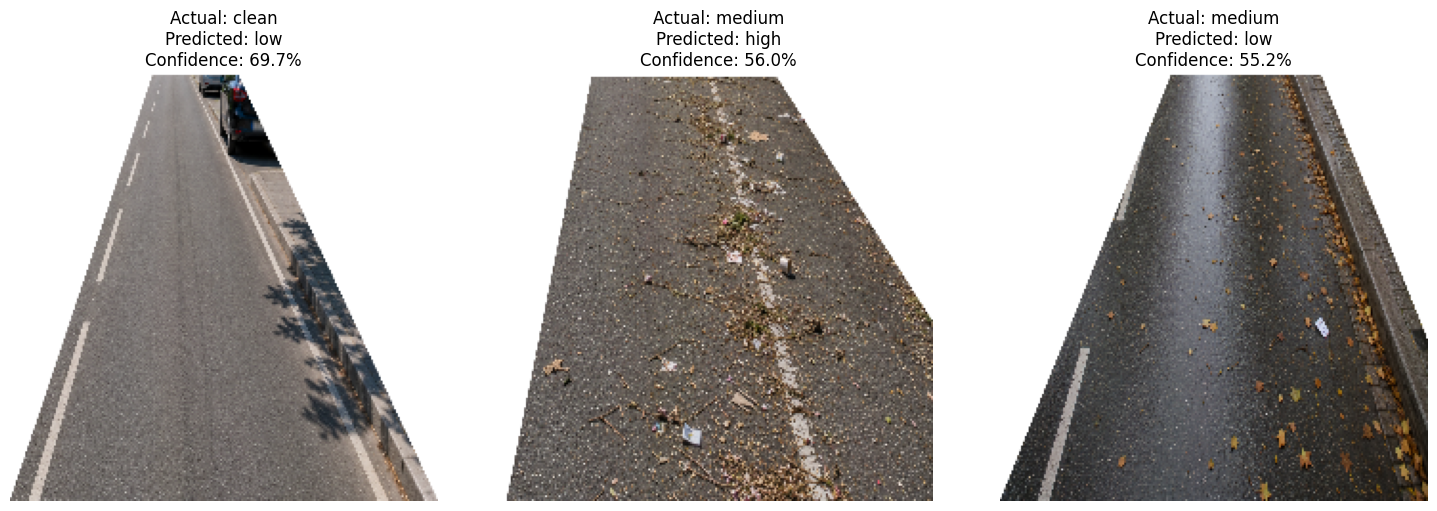

In [ ]:
# ============================================================
# COLLECT TEST IMAGES
# ============================================================

test_images = []
test_labels = []

for images, labels in test_ds:

    test_images.extend(
        images.numpy()
    )

    test_labels.extend(
        labels.numpy()
    )

test_images = np.array(test_images)
test_labels = np.array(test_labels)


# ============================================================
# DISPLAY MISCLASSIFIED IMAGES
# ============================================================

num_wrong = len(wrong_indices)

plt.figure(
    figsize=(5 * num_wrong, 5)
)

for plot_position, idx in enumerate(
    wrong_indices
):

    plt.subplot(
        1,
        num_wrong,
        plot_position + 1
    )

    plt.imshow(
        test_images[idx].astype("uint8")
    )

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]
    confidence = y_confidence[idx]

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence*100:.1f}%"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PREDICTION CONFIDENCE SUMMARY
# ============================================================

correct_mask = (
    y_true == y_pred
)

correct_confidence = y_confidence[
    correct_mask
]

wrong_confidence = y_confidence[
    ~correct_mask
]


print("======================================")
print("CONFIDENCE ANALYSIS")
print("======================================")

print(
    f"Average confidence - Correct : "
    f"{np.mean(correct_confidence)*100:.2f}%"
)

print(
    f"Average confidence - Wrong   : "
    f"{np.mean(wrong_confidence)*100:.2f}%"
)

print(
    f"Lowest confidence            : "
    f"{np.min(y_confidence)*100:.2f}%"
)

print(
    f"Highest confidence           : "
    f"{np.max(y_confidence)*100:.2f}%"
)

print("======================================")

CONFIDENCE ANALYSIS
Average confidence - Correct : 79.65%
Average confidence - Wrong   : 60.31%
Lowest confidence            : 53.38%
Highest confidence           : 99.08%


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/dataset_cropped/mobilenetv2_debris_classifier.keras"

model.save(MODEL_PATH)

print("Model saved successfully ✅")
print(MODEL_PATH)

Model saved successfully ✅
/content/drive/MyDrive/dataset_cropped/mobilenetv2_debris_classifier.keras


In [ ]:
import json

CLASS_PATH = "/content/drive/MyDrive/dataset_cropped/class_names.json"

with open(CLASS_PATH, "w") as f:
    json.dump(class_names, f)

print("Class names saved ✅")
print(class_names)

Class names saved ✅
['clean', 'high', 'low', 'medium']


In [ ]:
import tensorflow as tf
import json

MODEL_PATH = "/content/drive/MyDrive/dataset_cropped/mobilenetv2_debris_classifier.keras"
CLASS_PATH = "/content/drive/MyDrive/dataset_cropped/class_names.json"

# Load model
loaded_model = tf.keras.models.load_model(MODEL_PATH)

# Load class names
with open(CLASS_PATH, "r") as f:
    loaded_class_names = json.load(f)

print("Model loaded successfully ✅")
print("Classes:", loaded_class_names)

Model loaded successfully ✅
Classes: ['clean', 'high', 'low', 'medium']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_3.jpg to test_3 (1).jpg


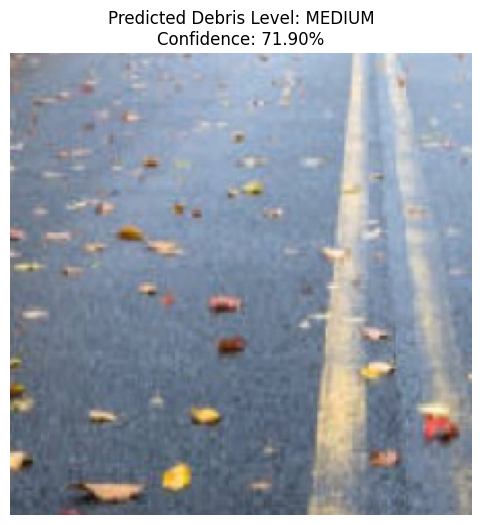

CNN PREDICTION
Debris Level : MEDIUM
Confidence   : 71.90%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Load image
img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)

# Add batch dimension
input_image = np.expand_dims(
    img_array,
    axis=0
)

# Predict
prediction = loaded_model.predict(
    input_image,
    verbose=0
)

predicted_index = np.argmax(prediction[0])

predicted_class = loaded_class_names[
    predicted_index
]

confidence = prediction[0][
    predicted_index
]


# Display
plt.figure(figsize=(8, 6))

plt.imshow(img)

plt.title(
    f"Predicted Debris Level: {predicted_class.upper()}\n"
    f"Confidence: {confidence*100:.2f}%"
)

plt.axis("off")
plt.show()


print("====================================")
print("CNN PREDICTION")
print("====================================")
print("Debris Level :", predicted_class.upper())
print(f"Confidence   : {confidence*100:.2f}%")
print("====================================")

In [ ]:
SAVED_MODEL_PATH = "/content/drive/MyDrive/dataset_cropped/mobilenetv2_savedmodel"

loaded_model.export(SAVED_MODEL_PATH)

print("TensorFlow SavedModel exported successfully ✅")
print(SAVED_MODEL_PATH)

Saved artifact at '/content/drive/MyDrive/dataset_cropped/mobilenetv2_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139010379512336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139010379511184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139010379510032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139010379511760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139010379501392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139010022457808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139010022458960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139010379512528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139010022458384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139010022459344: TensorSpec(shape=(), 

In [ ]:
import os

print(os.listdir(SAVED_MODEL_PATH))

['variables', 'assets', 'saved_model.pb', 'fingerprint.pb']
